In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import plotly.express as px


In [2]:
df=pd.read_csv("diabetes.csv")

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
  x=df.drop('Outcome',axis=1)
  y=df['Outcome']
  x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
  svm=SVC(C=1,random_state=42,kernel='rbf')
  svm.fit(x_train,y_train)
  y_pred=svm.predict(x_test)
  print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.88      0.83        99
           1       0.72      0.56      0.63        55

    accuracy                           0.77       154
   macro avg       0.75      0.72      0.73       154
weighted avg       0.76      0.77      0.76       154



In [6]:
dd=pd.read_csv("Teen_Mental_Health_Dataset.csv")

In [7]:
dd

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [8]:
dd=dd.dropna()

In [9]:
dd.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [11]:
x=dd.drop("depression_label",axis=1)
y=dd["depression_label"]
x=pd.get_dummies(x)
test=[0.05,0.1,0.15,0.2,0.25]
d={'model':[],'acc':[],'test_size':[]}
for i in test:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=42)
    knn=KNeighborsClassifier(n_neighbors=29)
    knn.fit(x_train,y_train)
    d['acc'].append(accuracy_score(y_test,knn.predict(x_test)))
    d['model'].append('knn')
    d['test_size'].append(i)
    dt=DecisionTreeClassifier(criterion='entropy',max_depth=4,random_state=42)
    dt.fit(x_train,y_train)
    d['acc'].append(accuracy_score(y_test,dt.predict(x_test)))
    d['model'].append('dt')
    d['test_size'].append(i)
    rf=RandomForestClassifier(n_estimators=100,max_depth=4,random_state=42,criterion='entropy')
    rf.fit(x_train,y_train)
    d['acc'].append(accuracy_score(y_test,rf.predict(x_test)))
    d['model'].append('rf')
    d['test_size'].append(i)
    svm=SVC(C=10,kernel='rbf',random_state=42)
    svm.fit(x_train,y_train)
    d['acc'].append(accuracy_score(y_test,svm.predict(x_test)))
    d['model'].append('svm')
    d['test_size'].append(i)
dd=pd.DataFrame(d)
dd

,model,acc,test_size
0,knn,0.933333,0.05
1,dt,1.000000,0.05
2,rf,0.933333,0.05
3,svm,0.950000,0.05
4,knn,0.958333,0.10
5,dt,1.000000,0.10
6,rf,0.958333,0.10
7,svm,0.975000,0.10
8,knn,0.972222,0.15
9,dt,1.000000,0.15


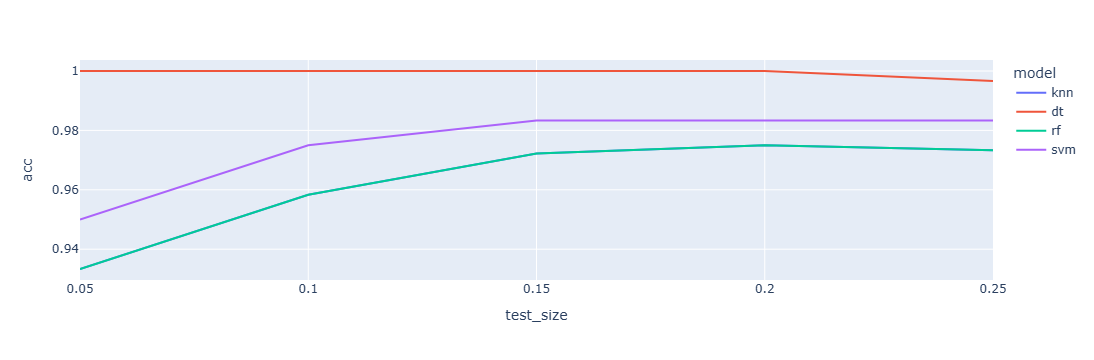

In [13]:
px.line(data_frame=dd,x='test_size',y='acc',color='model')

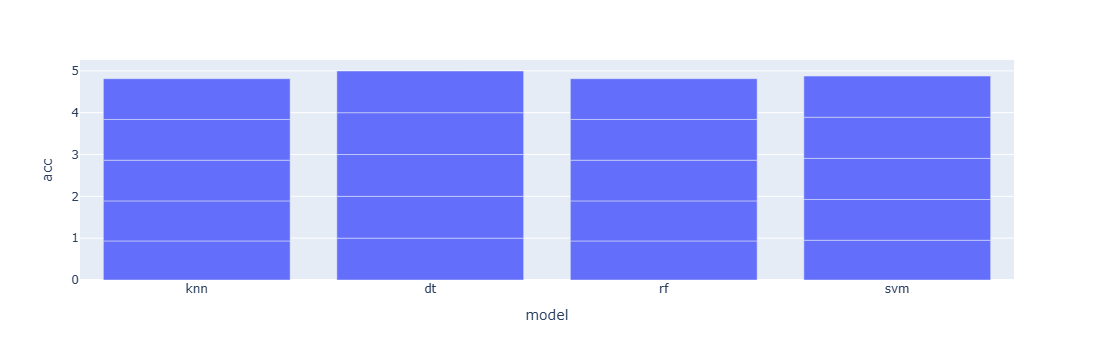

In [14]:
result=dd.groupby('model')['acc'].max().reset_index()
px.bar(data_frame=dd,x='model',y='acc')

In [4]:
import pandas as pd
df1=pd.read_csv("created_house_price_prediction.csv")
df1=df1.dropna()
x=df1.drop('Price',axis=1)
y=df1['Price']
x=pd.get_dummies(x)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=42)
r2=0
for i in range(1,9):
    poly=PolynomialFeatures(degree=i)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    lr=LinearRegression()
    lr.fit(x_train_poly,y_train)
    y_pred=lr.predict(x_test_poly)
    r2_s=re_score(y_test,y_pred)
    print(r2_s)
    if r2<r2_s:
        deg=i
print('degree',deg,">",r2)

NameError: name 'train_test_split' is not defined